## 1. Obtenção dos dados

Os dados educacionais são consultados no BigQuery e armazenados sem alteração dos valores originais na camada Bronze.

Fonte: `basedosdados.br_inep_avaliacao_alfabetizacao`.


In [2]:
# Autenticação da conta Google para acesso ao BigQuery.

from google.colab import auth

auth.authenticate_user()


In [3]:
# Configuração do projeto e da pasta de dados brutos.

from pathlib import Path

import pandas as pd
from google.cloud import bigquery

PROJECT_ID = "alfabetizacao-brasil"

client = bigquery.Client(project=PROJECT_ID)

PASTA_BRONZE = Path("/content/alfabetizacao-brasil/data/bronze")
PASTA_BRONZE.mkdir(parents=True, exist_ok=True)

print(f"Projeto configurado: {PROJECT_ID}")
print(f"Pasta de extração: {PASTA_BRONZE}")


Projeto configurado: alfabetizacao-brasil
Pasta de extração: /content/alfabetizacao-brasil/data/bronze


In [4]:
# Extração e armazenamento das tabelas educacionais e de metas.

TABELAS = [
    "dicionario",
    "uf",
    "municipio",
    "meta_alfabetizacao_brasil",
    "meta_alfabetizacao_uf",
    "meta_alfabetizacao_municipio",
]

bases = {}
resumo_extracao = []

for tabela in TABELAS:
    sql = f"""
        SELECT *
        FROM `basedosdados.br_inep_avaliacao_alfabetizacao.{tabela}`
    """

    configuracao = bigquery.QueryJobConfig(
        maximum_bytes_billed=1024**3
    )

    job = client.query(sql, job_config=configuracao)

    df = job.to_dataframe(create_bqstorage_client=False)

    bases[tabela] = df

    df.to_parquet(
        PASTA_BRONZE / f"{tabela}.parquet",
        index=False
    )

    resumo_extracao.append({
        "tabela": tabela,
        "linhas": len(df),
        "colunas": len(df.columns),
        "mb_processados": (job.total_bytes_processed or 0) / 1024**2,
    })

    print(f"Extraída: {tabela} — {len(df):,} linhas")

display(pd.DataFrame(resumo_extracao))


Extraída: dicionario — 27 linhas
Extraída: uf — 145 linhas
Extraída: municipio — 23,995 linhas
Extraída: meta_alfabetizacao_brasil — 3 linhas
Extraída: meta_alfabetizacao_uf — 81 linhas
Extraída: meta_alfabetizacao_municipio — 10,704 linhas


,tabela,linhas,colunas,mb_processados
0,dicionario,27,5,0.001120
1,uf,145,15,0.009851
2,municipio,23995,15,1.747190
3,meta_alfabetizacao_brasil,3,11,0.000257
4,meta_alfabetizacao_uf,81,12,0.007032
5,meta_alfabetizacao_municipio,10704,13,1.097900


In [5]:
# Consulta dos códigos e das descrições da tabela de alunos.

dicionario = bases["dicionario"]

display(
    dicionario.loc[
        dicionario["id_tabela"].eq("alunos"),
        [
            "id_tabela",
            "nome_coluna",
            "chave",
            "valor",
            "cobertura_temporal",
        ],
    ].sort_values(["nome_coluna", "chave"])
)


,id_tabela,nome_coluna,chave,valor,cobertura_temporal
0,alunos,alfabetizado,0,Não,(1)
1,alunos,alfabetizado,1,Sim,(1)
2,alunos,preenchimento_caderno,0,Prova não preenchida,(1)
3,alunos,preenchimento_caderno,1,Prova preenchida,(1)
4,alunos,presenca,0,Ausente,(1)
5,alunos,presenca,1,Presente,(1)
10,alunos,rede,1,Federal,(1)
11,alunos,rede,2,Estadual,(1)
16,alunos,rede,3,Municipal,(1)
18,alunos,rede,4,Privada,(1)


## 2. Amostra de alunos

A amostra contém aproximadamente 10% dos registros de 2023 e 2024. A seleção usa um hash de ano, município, escola e aluno, sem considerar o resultado da avaliação. Com a mesma fonte, a seleção pode ser reproduzida.

Os registros sem avaliação válida são preservados na base bruta. A cobertura territorial e as chaves são verificadas antes da preparação para modelagem.


In [6]:
# Extração de uma amostra reproduzível de aproximadamente 10% dos registros.

sql_alunos = """
SELECT
    ano,
    id_municipio,
    id_escola,
    id_aluno,
    caderno,
    serie,
    rede,
    presenca,
    preenchimento_caderno,
    alfabetizado,
    proficiencia,
    peso_aluno
FROM `basedosdados.br_inep_avaliacao_alfabetizacao.alunos`
WHERE ano IN (2023, 2024)
  AND MOD(
      FARM_FINGERPRINT(
          TO_JSON_STRING(
              STRUCT(ano, id_municipio, id_escola, id_aluno)
          )
      ),
      10
  ) = 0
"""

configuracao = bigquery.QueryJobConfig(
    maximum_bytes_billed=1024**3
)

job = client.query(
    sql_alunos,
    job_config=configuracao
)

alunos_raw = job.to_dataframe(
    create_bqstorage_client=False
)

alunos_raw.to_parquet(
    PASTA_BRONZE / "alunos_amostra.parquet",
    index=False
)

print(f"Registros extraídos: {len(alunos_raw):,}")
print(
    "Memória utilizada: "
    f"{alunos_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB"
)

display(alunos_raw.head())


Registros extraídos: 386,367
Memória utilizada: 182.6 MB


,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno
0,2023,1301902,60000747,13012277,1,2,3,0,0,0,NaN,NaN
1,2023,2602902,60013123,26038724,1,2,3,0,0,0,NaN,NaN
2,2023,5007901,60040318,50718420,1,2,3,0,0,0,NaN,NaN
3,2024,1503606,60002544,15036075,1,2,3,0,0,0,NaN,NaN
4,2024,3106200,60018076,31184846,1,2,3,0,0,0,NaN,NaN


In [7]:
# Verificação das avaliações válidas, da cobertura municipal e das chaves da amostra.

avaliacao_valida = (
    alunos_raw["serie"].eq("2")
    & alunos_raw["presenca"].eq("1")
    & alunos_raw["preenchimento_caderno"].eq("1")
    & alunos_raw["proficiencia"].notna()
    & alunos_raw["alfabetizado"].isin(["0", "1"])
).fillna(False)

resumo_amostra = (
    alunos_raw
    .assign(avaliacao_valida=avaliacao_valida)
    .groupby(
        ["ano", "avaliacao_valida", "alfabetizado"],
        dropna=False
    )
    .size()
    .reset_index(name="qtd_registros")
)

display(resumo_amostra)

print("Municípios distintos por ano:")
display(
    alunos_raw.groupby("ano")["id_municipio"]
    .nunique()
    .rename("qtd_municipios")
    .reset_index()
)

chaves = ["ano", "id_municipio", "id_escola", "id_aluno"]

print(
    "Registros com chave incompleta:",
    int(alunos_raw[chaves].isna().any(axis=1).sum())
)

print(
    "Linhas excedentes com a mesma chave candidata:",
    int(alunos_raw.duplicated(subset=chaves).sum())
)


,ano,avaliacao_valida,alfabetizado,qtd_registros
0,2023,False,0,24412
1,2023,True,0,62231
2,2023,True,1,87942
3,2024,False,0,26600
4,2024,True,0,74670
5,2024,True,1,110512


Municípios distintos por ano:


,ano,qtd_municipios
0,2023,4819
1,2024,5450


Registros com chave incompleta: 0
Linhas excedentes com a mesma chave candidata: 0


In [8]:
# Exportação de uma cópia dos dados brutos em ZIP.

import shutil
from google.colab import files

arquivo_zip = shutil.make_archive(
    base_name="/content/alfabetizacao_bronze",
    format="zip",
    root_dir=str(PASTA_BRONZE.parent),
    base_dir=PASTA_BRONZE.name
)

files.download(arquivo_zip)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Verificação de duplicidades, chaves incompletas, anos e redes nas tabelas de apoio.

chaves_por_tabela = {
    "municipio": ["ano", "id_municipio", "serie", "rede"],
    "uf": ["ano", "sigla_uf", "serie", "rede"],
    "meta_alfabetizacao_municipio": ["ano", "id_municipio", "rede"],
    "meta_alfabetizacao_uf": ["ano", "sigla_uf", "rede"],
    "meta_alfabetizacao_brasil": ["ano", "rede"],
}

resumo_chaves = []

for nome, chaves in chaves_por_tabela.items():
    df = bases[nome]

    resumo_chaves.append({
        "tabela": nome,
        "linhas": len(df),
        "chaves_incompletas": int(
            df[chaves].isna().any(axis=1).sum()
        ),
        "duplicidades_na_chave": int(
            df.duplicated(subset=chaves).sum()
        ),
        "anos": ", ".join(
            sorted(df["ano"].dropna().astype(str).unique())
        ),
        "codigos_rede": ", ".join(
            sorted(df["rede"].dropna().astype(str).unique())
        ),
    })

display(pd.DataFrame(resumo_chaves))


,tabela,linhas,chaves_incompletas,duplicidades_na_chave,anos,codigos_rede
0,municipio,23995,0,0,"2023, 2024","0, 2, 3, 5"
1,uf,145,0,0,"2023, 2024","0, 2, 3, 5"
2,meta_alfabetizacao_municipio,10704,0,0,"2023, 2024",Municipal
3,meta_alfabetizacao_uf,81,0,0,"2023, 2024, 2025",Pública
4,meta_alfabetizacao_brasil,3,0,0,"2023, 2024, 2025",Pública


In [10]:
# Consulta das redes de ensino e dos valores das metas municipais.

display(
    bases["dicionario"].loc[
        bases["dicionario"]["nome_coluna"].eq("rede"),
        ["id_tabela", "nome_coluna", "chave", "valor"]
    ].sort_values(["id_tabela", "chave"])
)


display(
    bases["meta_alfabetizacao_municipio"][
        [
            "ano",
            "id_municipio",
            "rede",
            "taxa_alfabetizacao",
            "meta_alfabetizacao_2024",
            "meta_alfabetizacao_2025",
        ]
    ].head(10)
)


,id_tabela,nome_coluna,chave,valor
10,alunos,rede,1,Federal
11,alunos,rede,2,Estadual
16,alunos,rede,3,Municipal
18,alunos,rede,4,Privada
7,municipio,rede,0,"Total (Federal, Estadual, Municipal e Privada)"
9,municipio,rede,1,Federal
12,municipio,rede,2,Estadual
15,municipio,rede,3,Municipal
19,municipio,rede,4,Privada
20,municipio,rede,5,Pública (Estadual e Municipal)


,ano,id_municipio,rede,taxa_alfabetizacao,meta_alfabetizacao_2024,meta_alfabetizacao_2025
0,2023,4301750,Municipal,NaN,NaN,14.05
1,2024,4301750,Municipal,4.40,NaN,14.05
2,2024,2406908,Municipal,42.86,7.94,14.05
3,2023,2406908,Municipal,4.40,7.94,14.05
4,2023,1718501,Municipal,4.60,8.25,14.48
5,2024,1718501,Municipal,50.29,8.25,14.48
6,2024,2919900,Municipal,12.50,8.39,14.66
7,2023,2919900,Municipal,4.70,8.39,14.66
8,2023,2414456,Municipal,NaN,NaN,18.14
9,2024,2414456,Municipal,10.95,NaN,18.14


## 3. Preparação dos dados

A camada Silver reúne alunos do 2º ano presentes, com prova preenchida, proficiência disponível e classificação válida. Registros sem avaliação válida não são usados como exemplos de não alfabetização.

Os identificadores são mantidos como texto. A proficiência é usada para conferir a classificação, mas fica fora dos preditores.

A base recebe informações territoriais, resultados educacionais e indicadores municipais de 2010. As taxas do mesmo ano e as metas são destinadas à análise descritiva. A ausência de dados é preservada.

A Gold reúne os dados preparados. Treino e validação usam municípios distintos de 2023; o teste usa 2024 e pode incluir municípios presentes no treino.


In [12]:
# Seleção dos alunos elegíveis e validação da classificação de alfabetização.

PASTA_SILVER = PASTA_BRONZE.parent / "silver"
PASTA_SILVER.mkdir(parents=True, exist_ok=True)

alunos = alunos_raw.copy()

colunas_texto = [
    "id_municipio", "id_escola", "id_aluno", "caderno",
    "serie", "rede", "presenca",
    "preenchimento_caderno", "alfabetizado",
]

for coluna in colunas_texto:
    alunos[coluna] = alunos[coluna].astype("string").str.strip()

filtro_elegivel = (
    alunos["serie"].eq("2")
    & alunos["presenca"].eq("1")
    & alunos["preenchimento_caderno"].eq("1")
    & alunos["proficiencia"].notna()
    & alunos["alfabetizado"].isin(["0", "1"])
).fillna(False)

alunos_silver = alunos.loc[filtro_elegivel].copy()
alunos_silver["alfabetizado"] = (
    alunos_silver["alfabetizado"].astype("int8")
)

chaves_aluno = ["ano", "id_municipio", "id_escola", "id_aluno"]

assert not alunos_silver[chaves_aluno].isna().any().any(), \
    "Há identificadores ausentes."

assert not alunos_silver.duplicated(chaves_aluno).any(), \
    "Há duplicidades na chave de aluno."

assert (
    alunos_silver["alfabetizado"]
    == alunos_silver["proficiencia"].ge(743).astype("int8")
).all(), "Há divergência entre classificação e proficiência."

alunos_silver.to_parquet(
    PASTA_SILVER / "alunos_elegiveis.parquet",
    index=False
)

print(f"Registros na Bronze: {len(alunos_raw):,}")
print(f"Registros elegíveis na Silver: {len(alunos_silver):,}")
print(f"Registros não elegíveis: {len(alunos_raw) - len(alunos_silver):,}")


Registros na Bronze: 386,367
Registros elegíveis na Silver: 335,355
Registros não elegíveis: 51,012


In [13]:
# Integração dos resultados municipais por ano, município, série e rede.

municipio = bases["municipio"].copy()

for coluna in ["id_municipio", "serie", "rede"]:
    municipio[coluna] = (
        municipio[coluna].astype("string").str.strip()
    )

chaves_municipio = ["ano", "id_municipio", "serie", "rede"]

resultado_municipal = municipio[
    chaves_municipio + ["taxa_alfabetizacao"]
].rename(columns={
    "taxa_alfabetizacao": "taxa_municipal_mesmo_ano_descritiva"
})

alunos_contexto = alunos_silver.merge(
    resultado_municipal,
    on=chaves_municipio,
    how="left",
    validate="many_to_one",
    indicator="vinculo_resultado_municipal"
)

assert len(alunos_contexto) == len(alunos_silver), \
    "O cruzamento alterou a quantidade de alunos."

display(
    alunos_contexto.groupby(
        ["ano", "vinculo_resultado_municipal"],
        observed=True
    ).size().reset_index(name="qtd_alunos")
)


,ano,vinculo_resultado_municipal,qtd_alunos
0,2023,left_only,13
1,2023,both,150160
2,2024,left_only,5
3,2024,both,185177


In [14]:
# Verificação da cobertura do cruzamento municipal.

display(
    alunos_contexto.groupby("ano").agg(
        qtd_alunos=("alfabetizado", "size"),
        qtd_municipios=("id_municipio", "nunique"),
        qtd_sem_taxa_municipal=(
            "taxa_municipal_mesmo_ano_descritiva",
            lambda coluna: int(coluna.isna().sum())
        )
    ).reset_index()
)

sem_correspondencia = alunos_contexto.loc[
    alunos_contexto["vinculo_resultado_municipal"].eq("left_only"),
    chaves_municipio
].drop_duplicates()

display(sem_correspondencia.head(10))


,ano,qtd_alunos,qtd_municipios,qtd_sem_taxa_municipal
0,2023,150173,4804,13
1,2024,185182,5434,5


,ano,id_municipio,serie,rede
4348,2023,5107107,2,2
23806,2024,1709500,2,4
91502,2023,2414456,2,3
114104,2023,3115706,2,2
121962,2024,2412708,2,3
148865,2023,1600238,2,2
259885,2023,2409100,2,2
319345,2024,4305371,2,3


In [18]:
# Integração das metas da rede municipal à base de alunos.

metas_municipais = bases["meta_alfabetizacao_municipio"].copy()

for coluna in ["id_municipio", "rede"]:
    metas_municipais[coluna] = (
        metas_municipais[coluna].astype("string").str.strip()
    )

metas_municipais = metas_municipais.loc[
    metas_municipais["rede"].eq("Municipal")
].copy()

metas_municipais["rede"] = "3"

colunas_metas = [
    f"meta_alfabetizacao_{ano}"
    for ano in range(2024, 2031)
]

chaves_metas = ["ano", "id_municipio", "rede"]

metas_para_join = metas_municipais[
    chaves_metas + colunas_metas
].copy()


colunas_da_integracao = colunas_metas + [
    "vinculo_meta_municipal",
    "situacao_meta_municipal",
]

base_sem_metas = alunos_contexto.drop(
    columns=colunas_da_integracao,
    errors="ignore"
)


contexto_atualizado = base_sem_metas.merge(
    metas_para_join,
    on=chaves_metas,
    how="left",
    validate="many_to_one",
    indicator="vinculo_meta_municipal"
)

assert len(contexto_atualizado) == len(alunos_silver), \
    "O cruzamento de metas alterou a quantidade de alunos."

contexto_atualizado["situacao_meta_municipal"] = "não se aplica"

rede_municipal = contexto_atualizado["rede"].eq("3")

contexto_atualizado.loc[
    rede_municipal,
    "situacao_meta_municipal"
] = "sem correspondência"

contexto_atualizado.loc[
    rede_municipal
    & contexto_atualizado["vinculo_meta_municipal"].eq("both"),
    "situacao_meta_municipal"
] = "registro de metas localizado"

alunos_contexto = contexto_atualizado

display(
    alunos_contexto.groupby(
        ["ano", "situacao_meta_municipal"]
    ).size().reset_index(name="qtd_alunos")
)


,ano,situacao_meta_municipal,qtd_alunos
0,2023,não se aplica,13085
1,2023,registro de metas localizado,133865
2,2023,sem correspondência,3223
3,2024,não se aplica,24183
4,2024,registro de metas localizado,158881
5,2024,sem correspondência,2118


In [19]:
# Extração do diretório de municípios.

sql_diretorio = """
SELECT *
FROM `basedosdados.br_bd_diretorios_brasil.municipio`
"""

job_diretorio = client.query(
    sql_diretorio,
    job_config=bigquery.QueryJobConfig(
        maximum_bytes_billed=1024**3
    )
)

diretorio_municipios = job_diretorio.to_dataframe(
    create_bqstorage_client=False
)

diretorio_municipios.to_parquet(
    PASTA_BRONZE / "diretorio_municipios.parquet",
    index=False
)

bases["diretorio_municipios"] = diretorio_municipios

print(f"Municípios no diretório: {len(diretorio_municipios):,}")
print("\nColunas disponíveis:")
print(diretorio_municipios.columns.tolist())

display(diretorio_municipios.head(3))


Municípios no diretório: 5,571

Colunas disponíveis:
['id_municipio', 'id_municipio_6', 'id_municipio_tse', 'id_municipio_rf', 'id_municipio_bcb', 'nome', 'capital_uf', 'id_comarca', 'id_regiao_saude', 'nome_regiao_saude', 'id_regiao_imediata', 'nome_regiao_imediata', 'id_regiao_intermediaria', 'nome_regiao_intermediaria', 'id_microrregiao', 'nome_microrregiao', 'id_mesorregiao', 'nome_mesorregiao', 'id_regiao_metropolitana', 'nome_regiao_metropolitana', 'ddd', 'id_uf', 'sigla_uf', 'nome_uf', 'nome_regiao', 'amazonia_legal', 'centroide']


,id_municipio,id_municipio_6,id_municipio_tse,id_municipio_rf,id_municipio_bcb,nome,capital_uf,id_comarca,id_regiao_saude,nome_regiao_saude,...,nome_mesorregiao,id_regiao_metropolitana,nome_regiao_metropolitana,ddd,id_uf,sigla_uf,nome_uf,nome_regiao,amazonia_legal,centroide
0,5101837,510183,None,None,None,Boa Esperança do Norte,<NA>,None,None,None,...,None,None,None,None,51,MT,Mato Grosso,Centro-Oeste,1,POINT(-54.9417429754238 -13.463197935201)
1,1100205,110020,35,3,30719,Porto Velho,1,1100205,11004,Madeira-Mamoré,...,Madeira-Guaporé,101,Região Metropolitana de Porto Velho,69,11,RO,Rondônia,Norte,1,POINT(-64.3041357999869 -9.15394033687075)
2,1100338,110033,434,47,44516,Nova Mamoré,0,1100106,11004,Madeira-Mamoré,...,Madeira-Guaporé,None,None,69,11,RO,Rondônia,Norte,1,POINT(-64.6295025002404 -10.3822863210755)


In [20]:
# Inclusão dos nomes de município, UF e região.

colunas_territorio = [
    "nome_municipio",
    "sigla_uf",
    "nome_uf",
    "nome_regiao",
]

territorio = diretorio_municipios[
    ["id_municipio", "nome", "sigla_uf", "nome_uf", "nome_regiao"]
].copy()

territorio = territorio.rename(
    columns={"nome": "nome_municipio"}
)

territorio["id_municipio"] = (
    territorio["id_municipio"].astype("string").str.strip()
)

assert territorio["id_municipio"].notna().all(), \
    "O diretório contém código de município ausente."

assert not territorio["id_municipio"].duplicated().any(), \
    "O diretório contém códigos de município duplicados."

base_para_join = alunos_contexto.drop(
    columns=colunas_territorio + ["vinculo_territorio"],
    errors="ignore"
).copy()

base_para_join["id_municipio"] = (
    base_para_join["id_municipio"].astype("string").str.strip()
)

contexto_atualizado = base_para_join.merge(
    territorio,
    on="id_municipio",
    how="left",
    validate="many_to_one",
    indicator="vinculo_territorio"
)

assert len(contexto_atualizado) == len(alunos_silver), \
    "O cruzamento territorial alterou a quantidade de alunos."

alunos_contexto = contexto_atualizado

display(
    alunos_contexto.groupby(
        ["ano", "vinculo_territorio"],
        observed=True
    ).size().reset_index(name="qtd_alunos")
)


,ano,vinculo_territorio,qtd_alunos
0,2023,both,150173
1,2024,both,185182


In [21]:
# Integração dos resultados estaduais por ano, UF, série e rede.

resultado_uf = bases["uf"][
    ["ano", "sigla_uf", "serie", "rede", "taxa_alfabetizacao"]
].copy()

for coluna in ["sigla_uf", "serie", "rede"]:
    resultado_uf[coluna] = (
        resultado_uf[coluna].astype("string").str.strip()
    )

resultado_uf = resultado_uf.rename(columns={
    "taxa_alfabetizacao": "taxa_uf_mesmo_ano_descritiva"
})

base_para_join = alunos_contexto.drop(
    columns=[
        "taxa_uf_mesmo_ano_descritiva",
        "vinculo_resultado_uf",
    ],
    errors="ignore"
)

contexto_atualizado = base_para_join.merge(
    resultado_uf,
    on=["ano", "sigla_uf", "serie", "rede"],
    how="left",
    validate="many_to_one",
    indicator="vinculo_resultado_uf"
)

assert len(contexto_atualizado) == len(alunos_silver), \
    "O cruzamento estadual alterou a quantidade de alunos."

alunos_contexto = contexto_atualizado

display(
    alunos_contexto.groupby(
        ["ano", "vinculo_resultado_uf"],
        observed=True
    ).size().reset_index(name="qtd_alunos")
)


,ano,vinculo_resultado_uf,qtd_alunos
0,2023,both,150173
1,2024,left_only,2234
2,2024,both,182948


In [22]:
# Armazenamento da base intermediária e resumo das informações ausentes.

alunos_contexto.to_parquet(
    PASTA_SILVER / "alunos_contexto_parcial.parquet",
    index=False
)

display(
    alunos_contexto.groupby("ano").agg(
        qtd_alunos=("alfabetizado", "size"),
        qtd_municipios=("id_municipio", "nunique"),
        sem_territorio=("nome_municipio", lambda s: s.isna().sum()),
        sem_taxa_uf=(
            "taxa_uf_mesmo_ano_descritiva",
            lambda s: s.isna().sum()
        ),
    ).reset_index()
)


,ano,qtd_alunos,qtd_municipios,sem_territorio,sem_taxa_uf
0,2023,150173,4804,0,0
1,2024,185182,5434,0,2234


In [24]:
# Identificação dos grupos sem correspondência nos resultados estaduais.

display(
    alunos_contexto.loc[
        alunos_contexto["vinculo_resultado_uf"].eq("left_only")
    ]
    .groupby(["ano", "sigla_uf", "serie", "rede"], dropna=False)
    .size()
    .reset_index(name="qtd_alunos")
    .sort_values("qtd_alunos", ascending=False)
)


,ano,sigla_uf,serie,rede,qtd_alunos
0,2024,DF,2,2,2232
1,2024,TO,2,4,2


In [25]:
# Organização das metas estaduais e nacionais por ano da meta e referência da fonte.

metas_contexto = {}

for nivel, nome_tabela in [
    ("uf", "meta_alfabetizacao_uf"),
    ("brasil", "meta_alfabetizacao_brasil"),
]:
    df = bases[nome_tabela].copy()

    identificadores = ["ano", "rede"]

    if nivel == "uf":
        identificadores.append("sigla_uf")
        df["sigla_uf"] = df["sigla_uf"].astype("string").str.strip()

    df["rede"] = df["rede"].astype("string").str.strip()

    colunas_metas = [
        f"meta_alfabetizacao_{ano}"
        for ano in range(2024, 2031)
    ]


    metas_longas = df.melt(
        id_vars=identificadores,
        value_vars=colunas_metas,
        var_name="ano_meta",
        value_name="meta_percentual"
    ).rename(columns={"ano": "ano_referencia_fonte"})

    metas_longas["ano_meta"] = (
        metas_longas["ano_meta"]
        .str.extract(r"(\d{4})$", expand=False)
        .astype(int)
    )


    metas_contexto[nivel] = metas_longas

    metas_longas.to_parquet(
        PASTA_SILVER / f"metas_{nivel}.parquet",
        index=False
    )

    print(f"Metas {nivel}: {len(metas_longas):,} linhas")
    display(metas_longas.head(3))


Metas uf: 567 linhas


,ano_referencia_fonte,rede,sigla_uf,ano_meta,meta_percentual
0,2024,Pública,RR,2024,NaN
1,2023,Pública,RR,2024,NaN
2,2024,Pública,SE,2024,38.3


Metas brasil: 21 linhas


,ano_referencia_fonte,rede,ano_meta,meta_percentual
0,2025,Pública,2024,60.0
1,2024,Pública,2024,59.9
2,2023,Pública,2024,59.9


In [27]:
# Extração dos indicadores socioeconômicos municipais de 2010.

sql_socioeconomico = """
SELECT
    ano,
    id_municipio,
    populacao,
    idhm,
    renda_pc,
    taxa_analfabetismo_18_mais,
    taxa_agua_encanada,
    taxa_agua_esgoto_inadequados
FROM `basedosdados.mundo_onu_adh.municipio`
WHERE ano = 2010
"""

job_socioeconomico = client.query(
    sql_socioeconomico,
    job_config=bigquery.QueryJobConfig(
        maximum_bytes_billed=1024**3
    )
)

socioeconomico_raw = job_socioeconomico.to_dataframe(
    create_bqstorage_client=False
)

socioeconomico_raw.to_parquet(
    PASTA_BRONZE / "atlas_municipios_2010.parquet",
    index=False
)

bases["atlas_municipios_2010"] = socioeconomico_raw

print(f"Registros extraídos: {len(socioeconomico_raw):,}")
display(socioeconomico_raw.head())


Registros extraídos: 5,565


,ano,id_municipio,populacao,idhm,renda_pc,taxa_analfabetismo_18_mais,taxa_agua_encanada,taxa_agua_esgoto_inadequados
0,2010,1100015,24392,0.641,476.99,13.00,93.69,9.31
1,2010,1100023,90353,0.702,689.95,8.53,98.54,11.40
2,2010,1100031,6313,0.650,457.17,14.73,95.49,3.31
3,2010,1100049,78574,0.718,738.06,8.94,97.96,1.85
4,2010,1100056,17029,0.692,577.18,11.17,97.53,5.34


In [28]:
# Integração dos indicadores históricos e verificação dos valores ausentes.

socioeconomico = socioeconomico_raw.copy()

socioeconomico["id_municipio"] = (
    socioeconomico["id_municipio"].astype("string").str.strip()
)

assert socioeconomico["id_municipio"].notna().all(), \
    "Há municípios sem identificador."

assert not socioeconomico["id_municipio"].duplicated().any(), \
    "Há mais de um registro por município."


socioeconomico = socioeconomico.rename(columns={
    "ano": "ano_fonte_socioeconomica",
    "populacao": "populacao_2010",
    "idhm": "idhm_2010",
    "renda_pc": "renda_pc_2010",
    "taxa_analfabetismo_18_mais": "analfabetismo_adultos_2010",
    "taxa_agua_encanada": "agua_encanada_2010",
    "taxa_agua_esgoto_inadequados": "agua_esgoto_inadequados_2010",
})

colunas_socio = [
    coluna
    for coluna in socioeconomico.columns
    if coluna != "id_municipio"
]


base_para_join = alunos_contexto.drop(
    columns=colunas_socio + ["vinculo_socioeconomico"],
    errors="ignore"
)

contexto_atualizado = base_para_join.merge(
    socioeconomico,
    on="id_municipio",
    how="left",
    validate="many_to_one",
    indicator="vinculo_socioeconomico"
)

assert len(contexto_atualizado) == len(alunos_silver), \
    "O cruzamento alterou a quantidade de alunos."

alunos_contexto = contexto_atualizado

alunos_contexto.to_parquet(
    PASTA_SILVER / "alunos_contexto_parcial.parquet",
    index=False
)

display(
    alunos_contexto.groupby(
        ["ano", "vinculo_socioeconomico"],
        observed=True
    ).size().reset_index(name="qtd_alunos")
)

print("Percentual de valores ausentes nos atributos:")
display(
    alunos_contexto[
        [c for c in colunas_socio if c != "ano_fonte_socioeconomica"]
    ]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("percentual_ausente")
    .to_frame()
)


,ano,vinculo_socioeconomico,qtd_alunos
0,2023,left_only,71
1,2023,both,150102
2,2024,left_only,55
3,2024,both,185127


Percentual de valores ausentes nos atributos:


,percentual_ausente
populacao_2010,0.04
idhm_2010,0.04
renda_pc_2010,0.04
analfabetismo_adultos_2010,0.04
agua_encanada_2010,0.04
agua_esgoto_inadequados_2010,0.04


In [29]:
# Armazenamento da base analítica e definição das variáveis do modelo.

PASTA_GOLD = PASTA_BRONZE.parent / "gold"
PASTA_GOLD.mkdir(parents=True, exist_ok=True)

gold_alunos = alunos_contexto.copy()

FEATURES_NUMERICAS = [
    "populacao_2010",
    "idhm_2010",
    "renda_pc_2010",
    "analfabetismo_adultos_2010",
    "agua_encanada_2010",
    "agua_esgoto_inadequados_2010",
]

FEATURES_CATEGORICAS = [
    "rede",
    "sigla_uf",
]

FEATURES = FEATURES_NUMERICAS + FEATURES_CATEGORICAS
TARGET = "alfabetizado"

for coluna in FEATURES_NUMERICAS:
    gold_alunos[coluna] = pd.to_numeric(
        gold_alunos[coluna],
        errors="raise"
    ).astype("float64")

for coluna in FEATURES_CATEGORICAS:
    gold_alunos[coluna] = (
        gold_alunos[coluna].astype("string").str.strip()
    )

assert len(gold_alunos) == len(alunos_silver)
assert gold_alunos[TARGET].isin([0, 1]).all()
assert not gold_alunos.duplicated(
    ["ano", "id_municipio", "id_escola", "id_aluno"]
).any()

gold_alunos.to_parquet(
    PASTA_GOLD / "alunos_analitico.parquet",
    index=False
)


for nivel, tabela in metas_contexto.items():
    tabela.to_parquet(
        PASTA_GOLD / f"metas_{nivel}.parquet",
        index=False
    )

print(f"Gold salva: {len(gold_alunos):,} registros")
print("Variáveis numéricas:", FEATURES_NUMERICAS)
print("Variáveis categóricas:", FEATURES_CATEGORICAS)


Gold salva: 335,355 registros
Variáveis numéricas: ['populacao_2010', 'idhm_2010', 'renda_pc_2010', 'analfabetismo_adultos_2010', 'agua_encanada_2010', 'agua_esgoto_inadequados_2010']
Variáveis categóricas: ['rede', 'sigla_uf']


In [30]:
# Separação do treino e da validação por município em 2023, com teste em 2024.

from sklearn.model_selection import GroupShuffleSplit

base_2023 = (
    gold_alunos.loc[gold_alunos["ano"].eq(2023)]
    .copy()
    .reset_index(drop=True)
)

teste = (
    gold_alunos.loc[gold_alunos["ano"].eq(2024)]
    .copy()
    .reset_index(drop=True)
)

divisor = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

idx_treino, idx_validacao = next(
    divisor.split(
        base_2023,
        groups=base_2023["id_municipio"]
    )
)

treino = base_2023.iloc[idx_treino].copy()
validacao = base_2023.iloc[idx_validacao].copy()

assert set(treino["id_municipio"]).isdisjoint(
    set(validacao["id_municipio"])
), "Há municípios compartilhados entre treino e validação."

assert len(treino) + len(validacao) + len(teste) == len(gold_alunos)

for nome, tabela in [
    ("treino", treino),
    ("validacao", validacao),
    ("teste", teste),
]:
    tabela.to_parquet(
        PASTA_GOLD / f"{nome}.parquet",
        index=False
    )

display(pd.DataFrame([
    {
        "conjunto": nome,
        "ano": int(tabela["ano"].iloc[0]),
        "registros": len(tabela),
        "municipios": tabela["id_municipio"].nunique(),
    }
    for nome, tabela in [
        ("treino", treino),
        ("validacao", validacao),
        ("teste", teste),
    ]
]))


,conjunto,ano,registros,municipios
0,treino,2023,122978,3843
1,validacao,2023,27195,961
2,teste,2024,185182,5434


In [31]:
# Exportação de uma cópia das bases preparadas.

import shutil
from google.colab import files

arquivo_backup = shutil.make_archive(
    base_name="/content/alfabetizacao_dados_preparados",
    format="zip",
    root_dir=str(PASTA_BRONZE.parent.parent),
    base_dir="data"
)

files.download(arquivo_backup)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Análise exploratória

A exploração usa somente o conjunto de treino de 2023 e considera:

- Distribuição entre alfabetizados e não alfabetizados.
- Diferenças por região e rede de ensino.
- Distribuição, ausências e correlações dos indicadores municipais.
- Relação entre faixas de IDHM e alfabetização.

As taxas são proporções não ponderadas da amostra, não estimativas oficiais. Os indicadores socioeconômicos descrevem o município em 2010, não a condição individual das famílias. As associações não demonstram causalidade.


In [36]:
# Configuração da identidade visual e das funções de exportação dos gráficos.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

PASTA_PROJETO = PASTA_BRONZE.parent.parent
PASTA_IMAGENS = PASTA_PROJETO / "images"
PASTA_RELATORIOS = PASTA_PROJETO / "reports"

PASTA_IMAGENS.mkdir(parents=True, exist_ok=True)
PASTA_RELATORIOS.mkdir(parents=True, exist_ok=True)

PALETA = {
    "marsala": "#783650",
    "marsala_escuro": "#482536",
    "rosa": "#C998AB",
    "rosa_claro": "#EBDCE2",
    "fundo": "#FAF8F9",
    "texto": "#302A2E",
    "secundario": "#766C73",
    "grade": "#E6DFE3",
    "negativo": "#64778B",
}


CORES_CLASSES = {
    0: PALETA["rosa"],
    1: PALETA["marsala"],
}

sns.set_theme(style="white")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.facecolor": PALETA["fundo"],
    "axes.facecolor": PALETA["fundo"],
    "text.color": PALETA["texto"],
    "axes.labelcolor": PALETA["secundario"],
    "xtick.color": PALETA["secundario"],
    "ytick.color": PALETA["texto"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "savefig.facecolor": PALETA["fundo"],
    "svg.fonttype": "none",
})

def numero_br(valor, casas=0):
    return (
        f"{valor:,.{casas}f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

def criar_figura(titulo, subtitulo, rodape, tamanho=(12, 7)):
    fig, ax = plt.subplots(figsize=tamanho)
    fig.subplots_adjust(
        left=0.20, right=0.91, top=0.74, bottom=0.22
    )

    fig.text(
        0.07, 0.95,
        "ALFABETIZAÇÃO NO BRASIL",
        fontsize=10,
        fontweight="bold",
        color=PALETA["marsala"],
        va="top"
    )

    fig.text(
        0.07, 0.89,
        titulo,
        fontsize=23,
        fontweight="bold",
        va="top"
    )

    fig.text(
        0.07, 0.81,
        subtitulo,
        fontsize=11,
        color=PALETA["secundario"],
        va="top"
    )

    fig.text(
        0.07, 0.065,
        rodape,
        fontsize=9,
        color=PALETA["secundario"],
        va="bottom",
        linespacing=1.5
    )

    return fig, ax

def salvar_grafico(fig, nome):
    caminho = PASTA_IMAGENS / nome

    fig.savefig(
        caminho.with_suffix(".png"),
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        caminho.with_suffix(".svg"),
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

eda = treino.copy()

mapa_rede = {
    "1": "Federal",
    "2": "Estadual",
    "3": "Municipal",
    "4": "Privada",
}

eda["nome_rede"] = eda["rede"].map(mapa_rede)


,alfabetizado,qtd_alunos,classificacao,percentual
0,0,51003,Não alfabetizado,41.47
1,1,71975,Alfabetizado,58.53


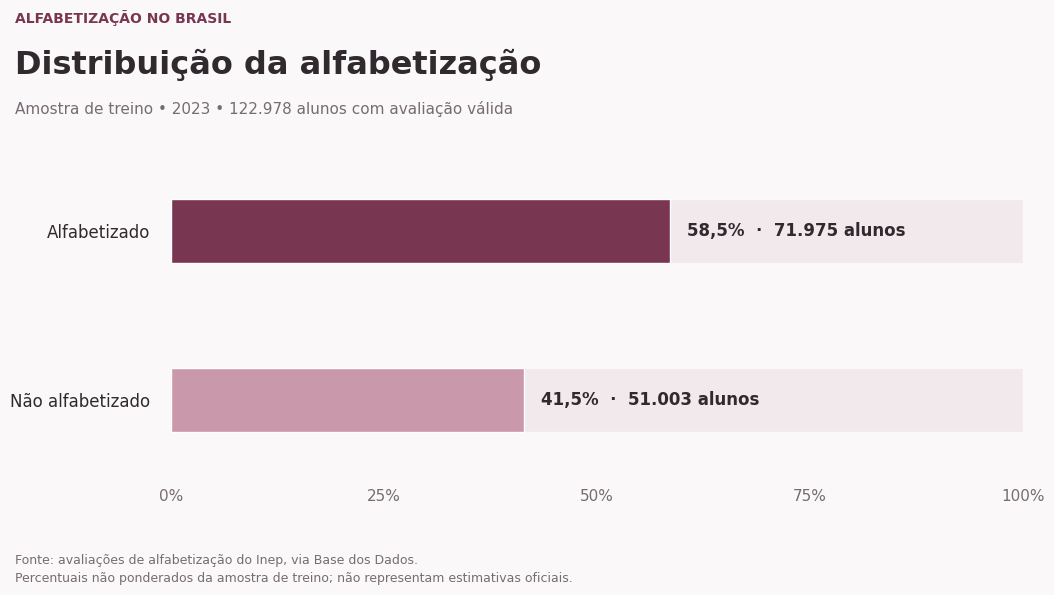

In [37]:
# Distribuição da alfabetização no conjunto de treino.

distribuicao = (
    eda["alfabetizado"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("alfabetizado")
    .reset_index(name="qtd_alunos")
)

distribuicao["classificacao"] = distribuicao["alfabetizado"].map({
    0: "Não alfabetizado",
    1: "Alfabetizado",
})

distribuicao["percentual"] = (
    distribuicao["qtd_alunos"]
    / distribuicao["qtd_alunos"].sum()
    * 100
)

display(distribuicao.round(2))

plot = distribuicao.sort_values(
    "alfabetizado", ascending=False
).reset_index(drop=True)

fig, ax = criar_figura(
    titulo="Distribuição da alfabetização",
    subtitulo=(
        f"Amostra de treino • 2023 • "
        f"{numero_br(len(eda))} alunos com avaliação válida"
    ),
    rodape=(
        "Fonte: avaliações de alfabetização do Inep, via Base dos Dados.\n"
        "Percentuais não ponderados da amostra de treino; "
        "não representam estimativas oficiais."
    ),
    tamanho=(12, 6.5)
)

posicoes = np.arange(len(plot))

ax.barh(
    posicoes,
    100,
    height=0.38,
    color=PALETA["rosa_claro"],
    alpha=0.50,
    zorder=1
)

ax.barh(
    posicoes,
    plot["percentual"],
    height=0.38,
    color=[CORES_CLASSES[c] for c in plot["alfabetizado"]],
    zorder=2
)

for posicao, linha in plot.iterrows():
    ax.text(
        linha["percentual"] + 2,
        posicao,
        (
            f"{numero_br(linha['percentual'], 1)}%  ·  "
            f"{numero_br(linha['qtd_alunos'])} alunos"
        ),
        va="center",
        fontsize=12,
        fontweight="bold"
    )

ax.set_yticks(posicoes)
ax.set_yticklabels(plot["classificacao"], fontsize=12)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_ylim(len(plot) - 0.5, -0.5)
ax.set_xticks([0, 25, 50, 75, 100])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:.0f}%")
)
ax.tick_params(axis="y", pad=15)

salvar_grafico(fig, "01_distribuicao_target.png")

distribuicao.to_csv(
    PASTA_RELATORIOS / "distribuicao_target_treino.csv",
    index=False
)


,nome_regiao,qtd_alunos,qtd_municipios,taxa_alfabetizacao_pct
0,Sul,24529,911,67.85
1,Sudeste,32015,819,59.24
2,Centro-Oeste,12746,366,58.51
3,Nordeste,40729,1434,54.63
4,Norte,12959,313,51.36


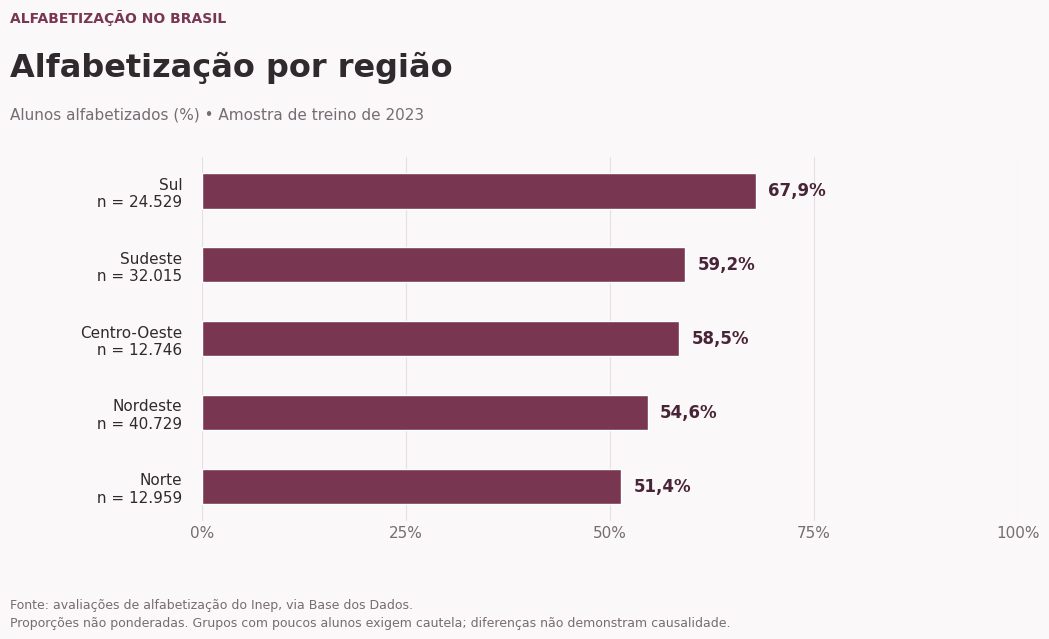

,nome_rede,qtd_alunos,qtd_municipios,taxa_alfabetizacao_pct
0,Estadual,10749,774,61.80
1,Municipal,112229,3786,58.21


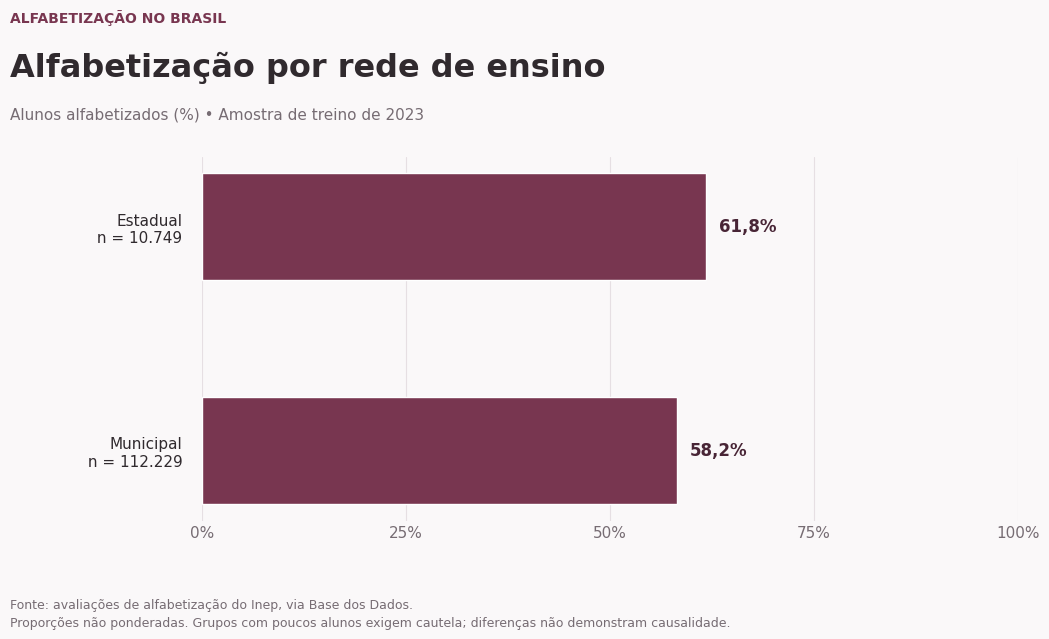

In [38]:
# Comparação das taxas da amostra por região e rede de ensino.

def resumo_por_grupo(coluna):
    resumo = (
        eda.groupby(coluna, dropna=False)
        .agg(
            qtd_alunos=("alfabetizado", "size"),
            qtd_municipios=("id_municipio", "nunique"),
            taxa_alfabetizacao=("alfabetizado", "mean"),
        )
        .reset_index()
    )

    resumo["taxa_alfabetizacao_pct"] = (
        resumo.pop("taxa_alfabetizacao") * 100
    )

    return resumo.sort_values(
        "taxa_alfabetizacao_pct",
        ascending=False
    ).reset_index(drop=True)

for coluna, titulo, arquivo in [
    (
        "nome_regiao",
        "Alfabetização por região",
        "02_alfabetizacao_regiao",
    ),
    (
        "nome_rede",
        "Alfabetização por rede de ensino",
        "03_alfabetizacao_rede",
    ),
]:
    resumo = resumo_por_grupo(coluna)
    display(resumo.round(2))

    fig, ax = criar_figura(
        titulo=titulo,
        subtitulo=(
            "Alunos alfabetizados (%) • Amostra de treino de 2023"
        ),
        rodape=(
            "Fonte: avaliações de alfabetização do Inep, via Base dos Dados.\n"
            "Proporções não ponderadas. Grupos com poucos alunos exigem cautela; "
            "diferenças não demonstram causalidade."
        )
    )

    fig.subplots_adjust(left=0.23)

    posicoes = np.arange(len(resumo))

    ax.barh(
        posicoes,
        resumo["taxa_alfabetizacao_pct"],
        height=0.48,
        color=PALETA["marsala"],
        zorder=3
    )

    rotulos = [
        f"{grupo}\n n = {numero_br(quantidade)}"
        for grupo, quantidade in zip(
            resumo[coluna].fillna("Não informado"),
            resumo["qtd_alunos"]
        )
    ]

    ax.set_yticks(posicoes)
    ax.set_yticklabels(rotulos, fontsize=11)
    ax.tick_params(axis="y", pad=14)

    for posicao, taxa in enumerate(
        resumo["taxa_alfabetizacao_pct"]
    ):

        dentro = taxa >= 88

        ax.text(
            taxa - 2 if dentro else taxa + 1.5,
            posicao,
            f"{numero_br(taxa, 1)}%",
            ha="right" if dentro else "left",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white" if dentro else PALETA["marsala_escuro"]
        )

    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{x:.0f}%")
    )
    ax.grid(
        axis="x",
        color=PALETA["grade"],
        linewidth=0.8,
        zorder=0
    )
    ax.set_axisbelow(True)

    salvar_grafico(fig, f"{arquivo}.png")

    resumo.to_csv(
        PASTA_RELATORIOS / f"{arquivo}.csv",
        index=False
    )


,count,mean,std,min,25%,50%,75%,max,percentual_ausente
populacao_2010,3839.0,31345.99,148389.11,1020.00,5435.00,10990.00,22733.00,6320446.00,0.1
idhm_2010,3839.0,0.65,0.07,0.44,0.59,0.65,0.70,0.85,0.1
renda_pc_2010,3839.0,466.34,236.61,96.25,267.65,417.88,619.00,2000.29,0.1
analfabetismo_adultos_2010,3839.0,18.73,10.85,0.97,9.55,16.29,27.85,47.38,0.1
agua_encanada_2010,3839.0,84.16,14.91,0.50,77.83,88.76,95.14,100.00,0.1
agua_esgoto_inadequados_2010,3839.0,10.20,13.11,0.00,0.78,4.60,14.98,76.98,0.1


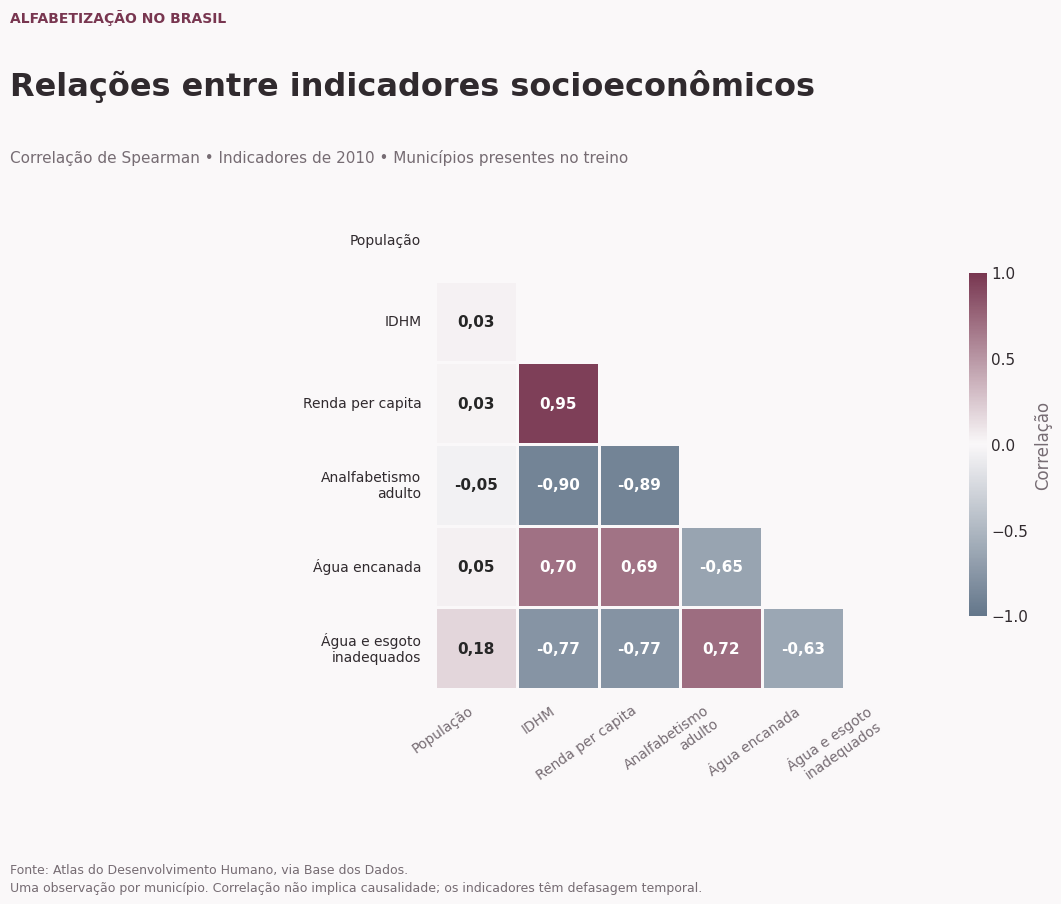

In [39]:
# Resumo e correlação dos indicadores socioeconômicos por município do treino.

contexto_municipal_treino = (
    eda[["id_municipio"] + FEATURES_NUMERICAS]
    .drop_duplicates(subset="id_municipio")
)

resumo_numerico = (
    contexto_municipal_treino[FEATURES_NUMERICAS]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
)

resumo_numerico["percentual_ausente"] = (
    contexto_municipal_treino[FEATURES_NUMERICAS]
    .isna()
    .mean()
    * 100
)

display(resumo_numerico.round(2))

resumo_numerico.to_csv(
    PASTA_RELATORIOS / "resumo_socioeconomico_municipios_treino.csv"
)

nomes_legiveis = {
    "populacao_2010": "População",
    "idhm_2010": "IDHM",
    "renda_pc_2010": "Renda per capita",
    "analfabetismo_adultos_2010": "Analfabetismo\nadulto",
    "agua_encanada_2010": "Água encanada",
    "agua_esgoto_inadequados_2010": "Água e esgoto\ninadequados",
}

correlacao = (
    contexto_municipal_treino[FEATURES_NUMERICAS]
    .rename(columns=nomes_legiveis)
    .corr(method="spearman")
)


mascara = np.triu(
    np.ones_like(correlacao, dtype=bool)
)

mapa_cores = LinearSegmentedColormap.from_list(
    "correlacao_projeto",
    [
        PALETA["negativo"],
        PALETA["fundo"],
        PALETA["marsala"],
    ]
)

anotacoes = correlacao.apply(
    lambda coluna: coluna.map(
        lambda valor: (
            numero_br(valor, 2)
            if pd.notna(valor)
            else ""
        )
    )
)

fig, ax = criar_figura(
    titulo="Relações entre indicadores socioeconômicos",
    subtitulo=(
        "Correlação de Spearman • Indicadores de 2010 • "
        "Municípios presentes no treino"
    ),
    rodape=(
        "Fonte: Atlas do Desenvolvimento Humano, via Base dos Dados.\n"
        "Uma observação por município. Correlação não implica causalidade; "
        "os indicadores têm defasagem temporal."
    ),
    tamanho=(13, 10)
)

fig.subplots_adjust(
    left=0.23, right=0.91, top=0.76, bottom=0.27
)

sns.heatmap(
    correlacao,
    mask=mascara,
    annot=anotacoes,
    fmt="",
    cmap=mapa_cores,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor=PALETA["fundo"],
    annot_kws={"fontsize": 11, "fontweight": "bold"},
    cbar_kws={
        "shrink": 0.70,
        "ticks": [-1, -0.5, 0, 0.5, 1],
        "label": "Correlação",
    },
    ax=ax
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
    fontsize=10
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=10
)

ax.tick_params(axis="both", pad=10)

salvar_grafico(fig, "04_correlacao_socioeconomica.png")


,faixa_idhm,qtd_alunos,qtd_municipios,idhm_minimo,idhm_maximo,taxa_alfabetizacao_pct
0,Q1 · Menor IDHM,15543,962,0.443,0.592,49.701
1,Q2 · IDHM intermediário,18375,968,0.593,0.651,58.531
2,Q3 · IDHM intermediário,22302,956,0.652,0.705,59.183
3,Q4 · Maior IDHM,66710,953,0.706,0.847,60.361


Alunos sem IDHM, não incluídos neste gráfico: 48


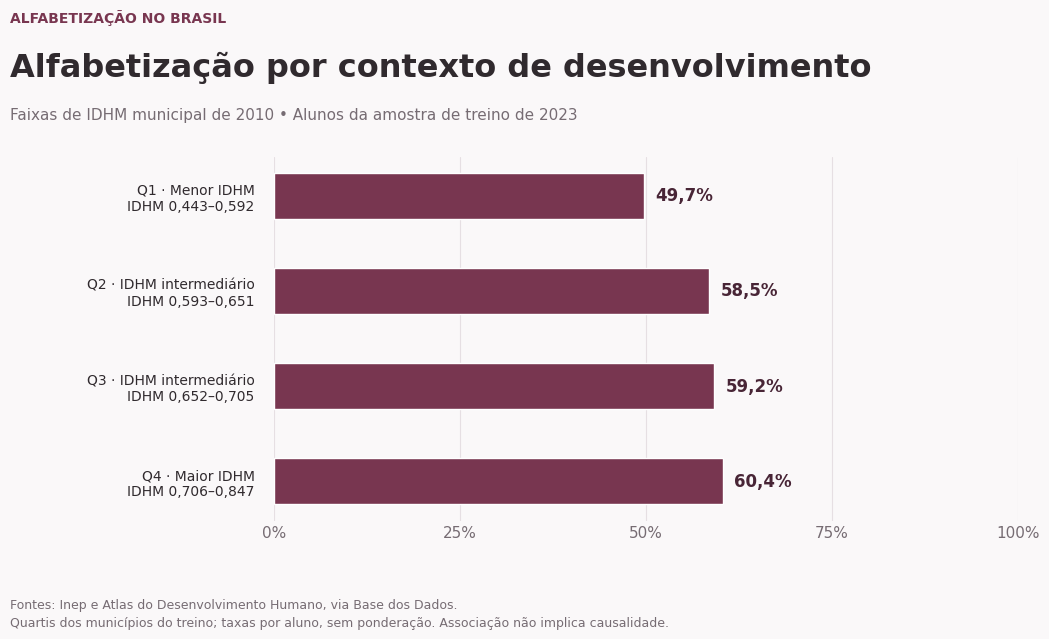

In [40]:
# Comparação da alfabetização por quartis de IDHM dos municípios do treino.

idhm_municipios = (
    eda[["id_municipio", "idhm_2010"]]
    .drop_duplicates(subset="id_municipio")
    .dropna(subset=["idhm_2010"])
    .copy()
)

rotulos_faixas = [
    "Q1 · Menor IDHM",
    "Q2 · IDHM intermediário",
    "Q3 · IDHM intermediário",
    "Q4 · Maior IDHM",
]

idhm_municipios["faixa_idhm"], limites_idhm = pd.qcut(
    idhm_municipios["idhm_2010"],
    q=4,
    labels=rotulos_faixas,
    retbins=True
)


eda_idhm = eda.drop(
    columns=["faixa_idhm"],
    errors="ignore"
).merge(
    idhm_municipios[["id_municipio", "faixa_idhm"]],
    on="id_municipio",
    how="left",
    validate="many_to_one"
)

resumo_idhm = (
    eda_idhm.groupby("faixa_idhm", observed=True)
    .agg(
        qtd_alunos=("alfabetizado", "size"),
        qtd_municipios=("id_municipio", "nunique"),
        idhm_minimo=("idhm_2010", "min"),
        idhm_maximo=("idhm_2010", "max"),
        taxa_alfabetizacao=("alfabetizado", "mean"),
    )
    .reset_index()
)

resumo_idhm["taxa_alfabetizacao_pct"] = (
    resumo_idhm.pop("taxa_alfabetizacao") * 100
)

display(resumo_idhm.round(3))

print(
    "Alunos sem IDHM, não incluídos neste gráfico:",
    int(eda_idhm["faixa_idhm"].isna().sum())
)

fig, ax = criar_figura(
    titulo="Alfabetização por contexto de desenvolvimento",
    subtitulo=(
        "Faixas de IDHM municipal de 2010 • "
        "Alunos da amostra de treino de 2023"
    ),
    rodape=(
        "Fontes: Inep e Atlas do Desenvolvimento Humano, via Base dos Dados.\n"
        "Quartis dos municípios do treino; taxas por aluno, sem ponderação. "
        "Associação não implica causalidade."
    ),
    tamanho=(12, 7)
)

fig.subplots_adjust(left=0.29)

posicoes = np.arange(len(resumo_idhm))

ax.barh(
    posicoes,
    resumo_idhm["taxa_alfabetizacao_pct"],
    height=0.48,
    color=PALETA["marsala"],
    zorder=3
)

rotulos = [
    (
        f"{linha.faixa_idhm}\n"
        f"IDHM {numero_br(linha.idhm_minimo, 3)}–"
        f"{numero_br(linha.idhm_maximo, 3)}"
    )
    for linha in resumo_idhm.itertuples()
]

ax.set_yticks(posicoes)
ax.set_yticklabels(rotulos, fontsize=10)
ax.tick_params(axis="y", pad=14)

for posicao, taxa in enumerate(
    resumo_idhm["taxa_alfabetizacao_pct"]
):
    dentro = taxa >= 88

    ax.text(
        taxa - 2 if dentro else taxa + 1.5,
        posicao,
        f"{numero_br(taxa, 1)}%",
        ha="right" if dentro else "left",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white" if dentro else PALETA["marsala_escuro"]
    )

ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:.0f}%")
)
ax.grid(
    axis="x",
    color=PALETA["grade"],
    linewidth=0.8
)
ax.set_axisbelow(True)

salvar_grafico(fig, "05_alfabetizacao_faixas_idhm.png")

resumo_idhm.to_csv(
    PASTA_RELATORIOS / "alfabetizacao_faixas_idhm_treino.csv",
    index=False
)


## 5. Modelagem e avaliação

O objetivo é prever a classificação de alfabetização de alunos com avaliação válida a partir da rede de ensino, da UF e de indicadores históricos do município.

Foram comparados DummyClassifier, regressão logística e Random Forest. A imputação, a padronização e a codificação das categorias são ajustadas somente no treino, dentro das pipelines.

O alvo mantém os códigos da fonte: **0 = não alfabetizado; 1 = alfabetizado**. Precisão, recall e F1 são avaliados para a classe 0, além das métricas gerais.

Configuração e limiar são selecionados na validação de 2023. A avaliação final usa 2024, sem novos ajustes com base no teste. A importância por permutação usa a validação; a análise territorial e a comparação com metas são descritivas.


In [41]:
# Preparação das variáveis de entrada e do alvo no treino e na validação.

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

def preparar_entradas(base):
    X = base[FEATURES].copy()

    for coluna in FEATURES_NUMERICAS:
        X[coluna] = pd.to_numeric(
            X[coluna], errors="raise"
        ).astype("float64")

    for coluna in FEATURES_CATEGORICAS:
        X[coluna] = (
            X[coluna]
            .astype(object)
            .where(X[coluna].notna(), np.nan)
        )

    return X

X_treino = preparar_entradas(treino)
y_treino = treino[TARGET].astype(int)

X_validacao = preparar_entradas(validacao)
y_validacao = validacao[TARGET].astype(int)

assert set(y_treino.unique()) == {0, 1}
assert set(y_validacao.unique()) == {0, 1}

print("Treino:", X_treino.shape)
print("Validação:", X_validacao.shape)
print("O teste não foi carregado para avaliação.")


Treino: (122978, 8)
Validação: (27195, 8)
O teste não foi carregado para avaliação.


In [42]:
# Definição do pré-processamento e dos três modelos iniciais.

def criar_preprocessamento(padronizar=False):
    etapas_numericas = [
        (
            "imputacao",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        )
    ]

    if padronizar:
        etapas_numericas.append(
            ("padronizacao", StandardScaler())
        )

    pipeline_numerica = Pipeline(etapas_numericas)

    pipeline_categorica = Pipeline([
        (
            "imputacao",
            SimpleImputer(
                strategy="constant",
                fill_value="Não informado"
            )
        ),
        (
            "encoding",
            OneHotEncoder(handle_unknown="ignore")
        ),
    ])

    return ColumnTransformer([
        (
            "numericas",
            pipeline_numerica,
            FEATURES_NUMERICAS
        ),
        (
            "categoricas",
            pipeline_categorica,
            FEATURES_CATEGORICAS
        ),
    ])

modelos = {
    "Referência — classe majoritária": Pipeline([
        ("preprocessamento", criar_preprocessamento()),
        ("modelo", DummyClassifier(strategy="most_frequent")),
    ]),

    "Regressão logística": Pipeline([
        (
            "preprocessamento",
            criar_preprocessamento(padronizar=True)
        ),
        (
            "modelo",
            LogisticRegression(
                C=1.0,
                max_iter=2000,
                random_state=42
            )
        ),
    ]),

    "Random Forest": Pipeline([
        ("preprocessamento", criar_preprocessamento()),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=10,
                min_samples_leaf=50,
                max_features="sqrt",
                n_jobs=-1,
                random_state=42
            )
        ),
    ]),
}


In [43]:
# Treinamento dos modelos e comparação das métricas na validação.

from time import perf_counter

resultados_modelos = []
previsoes_validacao = {}

for nome, pipeline in modelos.items():
    print(f"Treinando: {nome}", flush=True)

    inicio = perf_counter()
    pipeline.fit(X_treino, y_treino)
    tempo_treino = perf_counter() - inicio

    pred_treino = pipeline.predict(X_treino)
    pred_validacao = pipeline.predict(X_validacao)


    classes = pipeline.named_steps["modelo"].classes_
    indice_classe_zero = list(classes).index(0)

    prob_nao_alfabetizado = pipeline.predict_proba(
        X_validacao
    )[:, indice_classe_zero]

    alvo_risco = y_validacao.eq(0).astype(int)

    resultados_modelos.append({
        "modelo": nome,
        "acuracia_validacao": accuracy_score(
            y_validacao, pred_validacao
        ),
        "acuracia_balanceada": balanced_accuracy_score(
            y_validacao, pred_validacao
        ),
        "precisao_nao_alfabetizado": precision_score(
            y_validacao,
            pred_validacao,
            pos_label=0,
            zero_division=0
        ),
        "recall_nao_alfabetizado": recall_score(
            y_validacao,
            pred_validacao,
            pos_label=0,
            zero_division=0
        ),
        "f1_nao_alfabetizado": f1_score(
            y_validacao,
            pred_validacao,
            pos_label=0,
            zero_division=0
        ),
        "roc_auc_risco": roc_auc_score(
            alvo_risco, prob_nao_alfabetizado
        ),
        "average_precision_risco": average_precision_score(
            alvo_risco, prob_nao_alfabetizado
        ),
        "f1_treino_nao_alfabetizado": f1_score(
            y_treino,
            pred_treino,
            pos_label=0,
            zero_division=0
        ),
        "tempo_treino_segundos": tempo_treino,
    })

    previsoes_validacao[nome] = pd.DataFrame({
        "real": y_validacao.to_numpy(),
        "previsto": pred_validacao,
        "prob_nao_alfabetizado": prob_nao_alfabetizado,
    }, index=y_validacao.index)

    print(f"Concluído em {tempo_treino:.1f} segundos", flush=True)

comparacao_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values(
        "f1_nao_alfabetizado",
        ascending=False
    )
    .reset_index(drop=True)
)

comparacao_modelos["diferenca_f1_treino_validacao"] = (
    comparacao_modelos["f1_treino_nao_alfabetizado"]
    - comparacao_modelos["f1_nao_alfabetizado"]
)

display(comparacao_modelos.round(4))

comparacao_modelos.to_csv(
    PASTA_RELATORIOS / "comparacao_inicial_modelos.csv",
    index=False
)


Treinando: Referência — classe majoritária
Concluído em 0.7 segundos
Treinando: Regressão logística
Concluído em 3.2 segundos
Treinando: Random Forest
Concluído em 17.9 segundos


,modelo,acuracia_validacao,acuracia_balanceada,precisao_nao_alfabetizado,recall_nao_alfabetizado,f1_nao_alfabetizado,roc_auc_risco,average_precision_risco,f1_treino_nao_alfabetizado,tempo_treino_segundos,diferenca_f1_treino_validacao
0,Regressão logística,0.6200,0.5755,0.5711,0.3201,0.4103,0.6420,0.5351,0.4160,3.2136,0.0057
1,Random Forest,0.6168,0.5535,0.6163,0.1901,0.2906,0.6455,0.5423,0.3801,17.9082,0.0895
2,Referência — classe majoritária,0.5871,0.5000,0.0000,0.0000,0.0000,0.5000,0.4129,0.0000,0.7183,0.0000


In [45]:
# Treinamento de configurações adicionais de regressão logística e Random Forest.

from sklearn.base import clone

candidatos = {
    "Logística C=1": modelos["Regressão logística"],
    "Floresta profundidade=10": modelos["Random Forest"],
}

novas_configuracoes = {
    "Logística C=0.1": (
        modelos["Regressão logística"],
        {"modelo__C": 0.1}
    ),
    "Logística balanceada": (
        modelos["Regressão logística"],
        {"modelo__C": 1.0, "modelo__class_weight": "balanced"}
    ),
    "Floresta profundidade=6": (
        modelos["Random Forest"],
        {
            "modelo__max_depth": 6,
            "modelo__min_samples_leaf": 100,
        }
    ),
}

for nome, (modelo_base, parametros) in novas_configuracoes.items():
    print(f"Treinando: {nome}", flush=True)

    candidato = clone(modelo_base).set_params(**parametros)
    candidato.fit(X_treino, y_treino)

    candidatos[nome] = candidato

print("Candidatos prontos.")


Treinando: Logística C=0.1
Treinando: Logística balanceada
Treinando: Floresta profundidade=6
Candidatos prontos.


In [46]:
# Comparação dos limiares de risco pelo F1 da classe não alfabetizado.

limiares = np.round(np.arange(0.10, 0.901, 0.025), 3)

resultados_ajuste = []
probabilidades_candidatos = {}

for nome, pipeline in candidatos.items():
    classes = list(pipeline.named_steps["modelo"].classes_)
    indice_zero = classes.index(0)

    probabilidades = pipeline.predict_proba(
        X_validacao
    )[:, indice_zero]

    probabilidades_candidatos[nome] = probabilidades

    for limiar in limiares:


        previsao = np.where(probabilidades >= limiar, 0, 1)

        resultados_ajuste.append({
            "modelo": nome,
            "limiar": limiar,
            "precisao_nao_alfabetizado": precision_score(
                y_validacao, previsao,
                pos_label=0, zero_division=0
            ),
            "recall_nao_alfabetizado": recall_score(
                y_validacao, previsao,
                pos_label=0, zero_division=0
            ),
            "f1_nao_alfabetizado": f1_score(
                y_validacao, previsao,
                pos_label=0, zero_division=0
            ),
            "acuracia_balanceada": balanced_accuracy_score(
                y_validacao, previsao
            ),
            "percentual_sinalizado": 100 * np.mean(previsao == 0),
        })

tabela_ajuste = pd.DataFrame(resultados_ajuste)


melhores_por_modelo = (
    tabela_ajuste
    .sort_values(
        [
            "f1_nao_alfabetizado",
            "precisao_nao_alfabetizado",
            "limiar",
        ],
        ascending=[False, False, False]
    )
    .drop_duplicates("modelo")
    .reset_index(drop=True)
)

display(melhores_por_modelo.round(4))

tabela_ajuste.to_csv(
    PASTA_RELATORIOS / "avaliacao_limiares_validacao.csv",
    index=False
)

melhores_por_modelo.to_csv(
    PASTA_RELATORIOS / "melhores_configuracoes_validacao.csv",
    index=False
)


,modelo,limiar,precisao_nao_alfabetizado,recall_nao_alfabetizado,f1_nao_alfabetizado,acuracia_balanceada,percentual_sinalizado
0,Logística C=0.1,0.350,0.4711,0.8587,0.6084,0.5904,75.2638
1,Floresta profundidade=10,0.350,0.4576,0.9037,0.6075,0.5752,81.5444
2,Logística balanceada,0.350,0.4463,0.9499,0.6073,0.5607,87.8617
3,Logística C=1,0.275,0.4463,0.9499,0.6073,0.5607,87.8617
4,Floresta profundidade=6,0.350,0.4484,0.9362,0.6064,0.5631,86.2107


In [47]:
# Avaliação da referência que sinaliza todos os alunos como não alfabetizados.

previsao_todos_em_risco = np.zeros(
    len(y_validacao), dtype=int
)

referencia_todos_risco = pd.DataFrame([{
    "modelo": "Referência — todos sinalizados",
    "precisao_nao_alfabetizado": precision_score(
        y_validacao,
        previsao_todos_em_risco,
        pos_label=0,
        zero_division=0
    ),
    "recall_nao_alfabetizado": recall_score(
        y_validacao,
        previsao_todos_em_risco,
        pos_label=0,
        zero_division=0
    ),
    "f1_nao_alfabetizado": f1_score(
        y_validacao,
        previsao_todos_em_risco,
        pos_label=0,
        zero_division=0
    ),
    "percentual_sinalizado": 100.0,
}])

display(referencia_todos_risco.round(4))


,modelo,precisao_nao_alfabetizado,recall_nao_alfabetizado,f1_nao_alfabetizado,percentual_sinalizado
0,Referência — todos sinalizados,0.4129,1.0,0.5844,100.0


In [49]:
# Definição do modelo e do limiar selecionados na validação.

NOME_MODELO_FINAL = "Logística C=0.1"
LIMIAR_FINAL = 0.35

modelo_final = candidatos[NOME_MODELO_FINAL]

print("Modelo selecionado:", NOME_MODELO_FINAL)
print("Limiar de risco:", LIMIAR_FINAL)
print("Seleção realizada exclusivamente na validação de 2023.")


Modelo selecionado: Logística C=0.1
Limiar de risco: 0.35
Seleção realizada exclusivamente na validação de 2023.


In [50]:
# Avaliação final no teste de 2024 e comparação com as referências.

X_teste = preparar_entradas(teste)
y_teste = teste[TARGET].astype(int)

classes = list(modelo_final.named_steps["modelo"].classes_)
indice_zero = classes.index(0)

prob_risco_teste = modelo_final.predict_proba(
    X_teste
)[:, indice_zero]

pred_teste = np.where(
    prob_risco_teste >= LIMIAR_FINAL,
    0,
    1
)

def avaliar_classificacao(y_real, previsao, nome):
    return {
        "modelo": nome,
        "acuracia": accuracy_score(y_real, previsao),
        "acuracia_balanceada": balanced_accuracy_score(
            y_real, previsao
        ),
        "precisao_nao_alfabetizado": precision_score(
            y_real, previsao, pos_label=0, zero_division=0
        ),
        "recall_nao_alfabetizado": recall_score(
            y_real, previsao, pos_label=0, zero_division=0
        ),
        "f1_nao_alfabetizado": f1_score(
            y_real, previsao, pos_label=0, zero_division=0
        ),
        "percentual_sinalizado": 100 * np.mean(previsao == 0),
    }


classe_majoritaria = int(y_treino.mode().iloc[0])

resultado_teste = pd.DataFrame([
    avaliar_classificacao(
        y_teste,
        pred_teste,
        "Logística C=0.1 | limiar=0.35"
    ),
    avaliar_classificacao(
        y_teste,
        np.full(len(y_teste), classe_majoritaria),
        "Referência — classe majoritária do treino"
    ),
    avaliar_classificacao(
        y_teste,
        np.zeros(len(y_teste), dtype=int),
        "Referência — todos sinalizados"
    ),
])

display(resultado_teste.round(4))

metricas_probabilidade = pd.DataFrame([{
    "roc_auc_risco": roc_auc_score(
        y_teste.eq(0).astype(int),
        prob_risco_teste
    ),
    "average_precision_risco": average_precision_score(
        y_teste.eq(0).astype(int),
        prob_risco_teste
    ),
    "prevalencia_nao_alfabetizado": y_teste.eq(0).mean(),
}])

display(metricas_probabilidade.round(4))

resultado_teste.to_csv(
    PASTA_RELATORIOS / "avaliacao_final_teste_2024.csv",
    index=False
)

metricas_probabilidade.to_csv(
    PASTA_RELATORIOS / "metricas_probabilidade_teste_2024.csv",
    index=False
)


,modelo,acuracia,acuracia_balanceada,precisao_nao_alfabetizado,recall_nao_alfabetizado,f1_nao_alfabetizado,percentual_sinalizado
0,Logística C=0.1 | limiar=0.35,0.4945,0.5547,0.4361,0.8654,0.5800,80.0148
1,Referência — classe majoritária do treino,0.5968,0.5000,0.0000,0.0000,0.0000,0.0000
2,Referência — todos sinalizados,0.4032,0.5000,0.4032,1.0000,0.5747,100.0000


,roc_auc_risco,average_precision_risco,prevalencia_nao_alfabetizado
0,0.6103,0.5073,0.4032


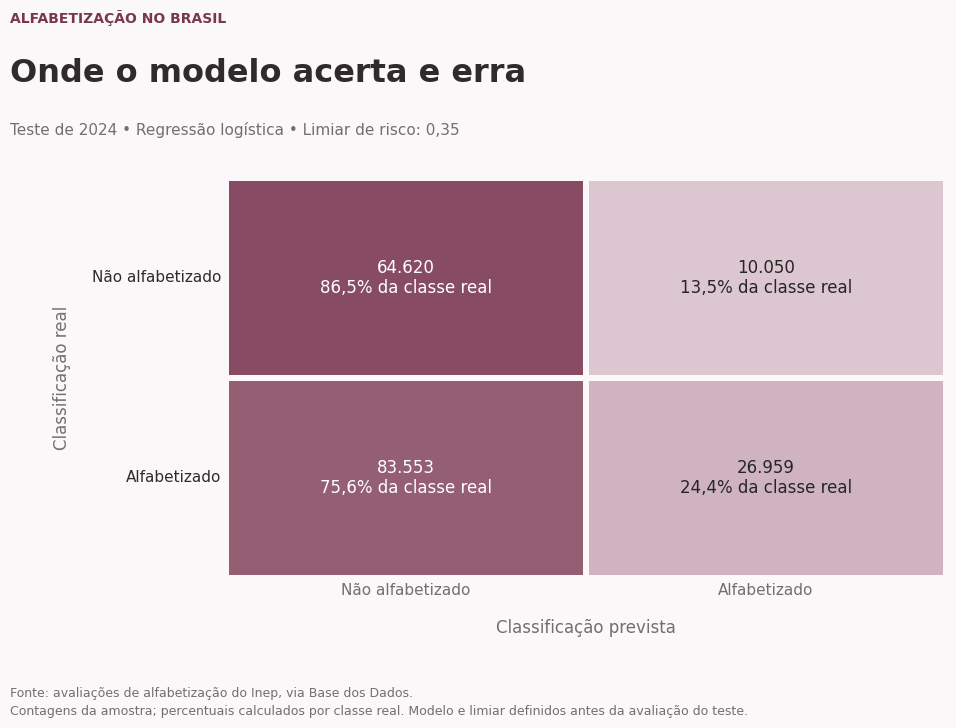

In [51]:
# Matriz de confusão com contagens e percentuais por classe real.

from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

matriz = confusion_matrix(
    y_teste,
    pred_teste,
    labels=[0, 1]
)

percentual_linha = (
    matriz
    / matriz.sum(axis=1, keepdims=True)
    * 100
)

anotacoes = np.array([
    [
        f"{numero_br(matriz[i, j])}\n"
        f"{numero_br(percentual_linha[i, j], 1)}% da classe real"
        for j in range(2)
    ]
    for i in range(2)
])

cmap_matriz = LinearSegmentedColormap.from_list(
    "matriz_marsala",
    [PALETA["rosa_claro"], PALETA["marsala"]]
)

fig, ax = criar_figura(
    titulo="Onde o modelo acerta e erra",
    subtitulo=(
        "Teste de 2024 • Regressão logística • "
        "Limiar de risco: 0,35"
    ),
    rodape=(
        "Fonte: avaliações de alfabetização do Inep, via Base dos Dados.\n"
        "Contagens da amostra; percentuais calculados por classe real. "
        "Modelo e limiar definidos antes da avaliação do teste."
    ),
    tamanho=(12, 8)
)

fig.subplots_adjust(
    left=0.25, right=0.85, top=0.74, bottom=0.24
)

sns.heatmap(
    percentual_linha,
    annot=anotacoes,
    fmt="",
    cmap=cmap_matriz,
    vmin=0,
    vmax=100,
    cbar=False,
    linewidths=3,
    linecolor=PALETA["fundo"],
    xticklabels=["Não alfabetizado", "Alfabetizado"],
    yticklabels=["Não alfabetizado", "Alfabetizado"],
    annot_kws={"fontsize": 12},
    ax=ax
)

ax.set_xlabel("Classificação prevista", labelpad=15)
ax.set_ylabel("Classificação real", labelpad=15)
ax.tick_params(axis="both", labelrotation=0)

salvar_grafico(fig, "06_matriz_confusao_teste.png")


In [52]:
# Armazenamento da pipeline, do limiar e das informações do modelo.

import joblib
import sklearn

PASTA_MODELOS = PASTA_PROJETO / "models"
PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

artefato_modelo = {
    "pipeline": modelo_final,
    "limiar_risco": LIMIAR_FINAL,
    "classe_risco": 0,
    "features": FEATURES,
    "target": TARGET,
    "sklearn_version": sklearn.__version__,
    "treino": "Municípios selecionados de 2023",
    "validacao": "Municípios separados de 2023",
    "teste": "2024",
}

joblib.dump(
    artefato_modelo,
    PASTA_MODELOS / "modelo_alfabetizacao.joblib"
)

print("Modelo, variáveis e limiar salvos.")


Modelo, variáveis e limiar salvos.


In [53]:
# Cálculo da importância por permutação na validação de 2023.

from sklearn.inspection import permutation_importance

print("Calculando importância por permutação...", flush=True)

resultado_importancia = permutation_importance(
    modelo_final,
    X_validacao,
    y_validacao,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

importancia_variaveis = pd.DataFrame({
    "variavel": FEATURES,
    "queda_auc_media": resultado_importancia.importances_mean,
    "desvio_entre_repeticoes": resultado_importancia.importances_std,
})

nomes_variaveis = {
    "populacao_2010": "População municipal",
    "idhm_2010": "IDHM",
    "renda_pc_2010": "Renda per capita",
    "analfabetismo_adultos_2010": "Analfabetismo adulto",
    "agua_encanada_2010": "Água encanada",
    "agua_esgoto_inadequados_2010": "Água e esgoto inadequados",
    "rede": "Rede de ensino",
    "sigla_uf": "Unidade da Federação",
}

importancia_variaveis["nome"] = (
    importancia_variaveis["variavel"].map(nomes_variaveis)
)

importancia_variaveis = (
    importancia_variaveis
    .sort_values("queda_auc_media", ascending=False)
    .reset_index(drop=True)
)

display(importancia_variaveis.round(5))

importancia_variaveis.to_csv(
    PASTA_RELATORIOS / "importancia_permutacao_validacao.csv",
    index=False
)


Calculando importância por permutação...


,variavel,queda_auc_media,desvio_entre_repeticoes,nome
0,sigla_uf,0.13465,0.00423,Unidade da Federação
1,idhm_2010,0.03344,0.00143,IDHM
2,analfabetismo_adultos_2010,0.01736,0.00090,Analfabetismo adulto
3,renda_pc_2010,0.00351,0.00061,Renda per capita
4,agua_esgoto_inadequados_2010,0.00247,0.00054,Água e esgoto inadequados
5,agua_encanada_2010,0.00098,0.00025,Água encanada
6,rede,0.00092,0.00027,Rede de ensino
7,populacao_2010,-0.00069,0.00008,População municipal


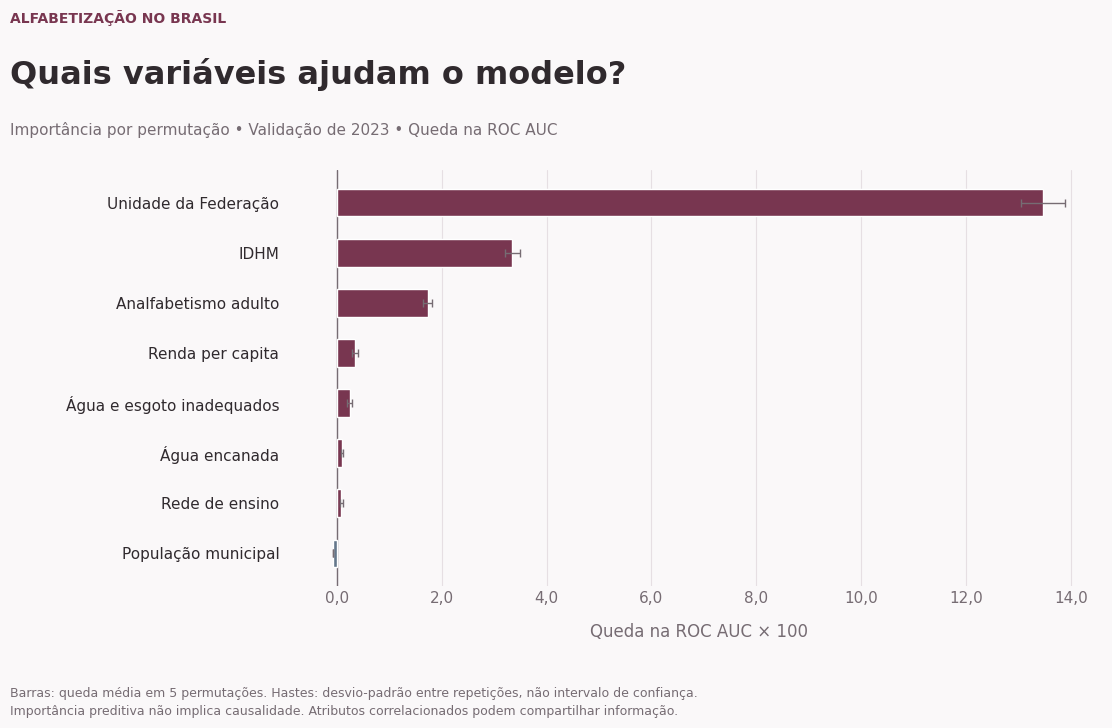

In [54]:
# Visualização da queda na ROC AUC após a permutação de cada variável.

plot_importancia = importancia_variaveis.copy()


valores = plot_importancia["queda_auc_media"] * 100
desvios = plot_importancia["desvio_entre_repeticoes"] * 100

fig, ax = criar_figura(
    titulo="Quais variáveis ajudam o modelo?",
    subtitulo=(
        "Importância por permutação • Validação de 2023 • "
        "Queda na ROC AUC"
    ),
    rodape=(
        "Barras: queda média em 5 permutações. Hastes: desvio-padrão "
        "entre repetições, não intervalo de confiança.\n"
        "Importância preditiva não implica causalidade. "
        "Atributos correlacionados podem compartilhar informação."
    ),
    tamanho=(13, 8)
)

fig.subplots_adjust(left=0.29, right=0.91, top=0.75, bottom=0.23)

posicoes = np.arange(len(plot_importancia))

ax.barh(
    posicoes,
    valores,
    xerr=desvios,
    height=0.55,
    color=[
        PALETA["marsala"] if valor >= 0 else PALETA["negativo"]
        for valor in valores
    ],
    error_kw={
        "ecolor": PALETA["secundario"],
        "capsize": 3,
        "elinewidth": 1,
    },
    zorder=3
)

ax.set_yticks(posicoes)
ax.set_yticklabels(plot_importancia["nome"], fontsize=11)
ax.tick_params(axis="y", pad=12)
ax.invert_yaxis()

ax.axvline(
    0,
    color=PALETA["secundario"],
    linewidth=1
)

ax.set_xlabel("Queda na ROC AUC × 100", labelpad=12)
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: numero_br(x, 1))
)

ax.grid(axis="x", color=PALETA["grade"], linewidth=0.8)
ax.set_axisbelow(True)

salvar_grafico(fig, "07_importancia_variaveis.png")


In [55]:
# Armazenamento das previsões individuais para análise territorial.

colunas_identificacao = [
    "ano",
    "id_municipio",
    "nome_municipio",
    "sigla_uf",
    "nome_regiao",
    "id_escola",
    "id_aluno",
    "rede",
    "peso_aluno",
]

predicoes_teste = teste[colunas_identificacao].copy()

predicoes_teste["alfabetizado_real"] = y_teste.to_numpy()
predicoes_teste["alfabetizado_previsto"] = pred_teste
predicoes_teste["escore_nao_alfabetizado"] = prob_risco_teste
predicoes_teste["sinalizado"] = pred_teste == 0

predicoes_teste.to_parquet(
    PASTA_GOLD / "predicoes_teste_2024.parquet",
    index=False
)

print(f"Previsões salvas: {len(predicoes_teste):,}")


Previsões salvas: 185,182


In [56]:
# Resumo municipal das previsões e seleção dos grupos com pelo menos 100 alunos.

analise_territorial = predicoes_teste.copy()

analise_territorial["nao_alfabetizado_real"] = (
    analise_territorial["alfabetizado_real"].eq(0)
)

resumo_municipios = (
    analise_territorial
    .groupby(
        ["id_municipio", "nome_municipio", "sigla_uf", "nome_regiao"],
        dropna=False
    )
    .agg(
        qtd_alunos=("alfabetizado_real", "size"),
        qtd_nao_alfabetizados=("nao_alfabetizado_real", "sum"),
        taxa_nao_alfabetizacao_amostra=("nao_alfabetizado_real", "mean"),
        escore_medio_modelo=("escore_nao_alfabetizado", "mean"),
        proporcao_sinalizada=("sinalizado", "mean"),
    )
    .reset_index()
)


MIN_ALUNOS_EXIBICAO = 100

municipios_exibicao = (
    resumo_municipios.loc[
        resumo_municipios["qtd_alunos"].ge(MIN_ALUNOS_EXIBICAO)
    ]
    .sort_values(
        ["escore_medio_modelo", "qtd_alunos"],
        ascending=[False, False]
    )
    .copy()
)

display(municipios_exibicao.head(10).round(4))

print(
    "Municípios com pelo menos 100 alunos na amostra:",
    len(municipios_exibicao)
)

resumo_municipios.to_csv(
    PASTA_RELATORIOS / "resultados_municipais_amostra_2024.csv",
    index=False
)


,id_municipio,nome_municipio,sigla_uf,nome_regiao,qtd_alunos,qtd_nao_alfabetizados,taxa_nao_alfabetizacao_amostra,escore_medio_modelo,proporcao_sinalizada
1765,2804805,Nossa Senhora do Socorro,SE,Nordeste,183,130,0.7104,0.7201,1.0
1721,2800308,Aracaju,SE,Nordeste,348,197,0.5661,0.7018,1.0
2023,2919553,Luís Eduardo Magalhães,BA,Nordeste,121,74,0.6116,0.6557,1.0
2161,2930709,Simões Filho,BA,Nordeste,127,83,0.6535,0.6532,1.0
2019,2919207,Lauro de Freitas,BA,Nordeste,132,87,0.6591,0.6530,1.0
1863,2905701,Camaçari,BA,Nordeste,239,145,0.6067,0.6479,1.0
1088,2403251,Parnamirim,RN,Nordeste,133,87,0.6541,0.6402,1.0
1140,2408102,Natal,RN,Nordeste,355,226,0.6366,0.6362,1.0
1922,2910800,Feira de Santana,BA,Nordeste,359,232,0.6462,0.6328,1.0
2097,2925303,Porto Seguro,BA,Nordeste,212,116,0.5472,0.6315,1.0


Municípios com pelo menos 100 alunos na amostra: 311


In [57]:
# Comparação retrospectiva dos resultados municipais com as metas de 2024.

comparacao_metas = bases["meta_alfabetizacao_municipio"].copy()

comparacao_metas["rede"] = (
    comparacao_metas["rede"].astype("string").str.strip()
)

comparacao_metas["id_municipio"] = (
    comparacao_metas["id_municipio"].astype("string").str.strip()
)

comparacao_metas = comparacao_metas.loc[
    comparacao_metas["ano"].eq(2024)
    & comparacao_metas["rede"].eq("Municipal"),
    [
        "ano",
        "id_municipio",
        "rede",
        "taxa_alfabetizacao",
        "meta_alfabetizacao_2024",
        "meta_alfabetizacao_2025",
    ]
].copy()

assert not comparacao_metas["id_municipio"].duplicated().any()

nomes_municipios = diretorio_municipios[
    ["id_municipio", "nome", "sigla_uf", "nome_regiao"]
].copy()

nomes_municipios["id_municipio"] = (
    nomes_municipios["id_municipio"].astype("string").str.strip()
)

comparacao_metas = comparacao_metas.merge(
    nomes_municipios,
    on="id_municipio",
    how="left",
    validate="one_to_one"
).rename(columns={"nome": "nome_municipio"})

campos_comparacao = [
    "taxa_alfabetizacao",
    "meta_alfabetizacao_2024",
]

for coluna in campos_comparacao:
    comparacao_metas[coluna] = pd.to_numeric(
        comparacao_metas[coluna], errors="raise"
    )

    valores = comparacao_metas[coluna].dropna()
    assert valores.between(0, 100).all(), \
        f"Valores fora da escala percentual em {coluna}."

comparavel = comparacao_metas[campos_comparacao].notna().all(axis=1)

comparacao_metas["situacao_meta_2024"] = "Sem dados para comparação"

comparacao_metas.loc[
    comparavel, "situacao_meta_2024"
] = "Abaixo da meta"

atingiu = (
    comparavel
    & comparacao_metas["taxa_alfabetizacao"].ge(
        comparacao_metas["meta_alfabetizacao_2024"]
    )
)

comparacao_metas.loc[
    atingiu, "situacao_meta_2024"
] = "Atingiu ou superou"

comparacao_metas["distancia_meta_2024_pp"] = (
    comparacao_metas["taxa_alfabetizacao"]
    - comparacao_metas["meta_alfabetizacao_2024"]
)

resumo_metas = (
    comparacao_metas["situacao_meta_2024"]
    .value_counts()
    .rename_axis("situacao")
    .reset_index(name="qtd_municipios")
)

display(resumo_metas)

display(
    comparacao_metas.loc[
        comparacao_metas["situacao_meta_2024"].eq("Abaixo da meta"),
        [
            "nome_municipio",
            "sigla_uf",
            "taxa_alfabetizacao",
            "meta_alfabetizacao_2024",
            "distancia_meta_2024_pp",
        ]
    ]
    .sort_values("distancia_meta_2024_pp")
    .head(10)
    .round(2)
)

comparacao_metas.to_csv(
    PASTA_RELATORIOS / "comparacao_metas_municipais_2024.csv",
    index=False
)


,situacao,qtd_municipios
0,Atingiu ou superou,2788
1,Abaixo da meta,2444
2,Sem dados para comparação,120


,nome_municipio,sigla_uf,taxa_alfabetizacao,meta_alfabetizacao_2024,distancia_meta_2024_pp
5078,Sério,RS,11.10,80.00,-68.90
5257,Arroio do Padre,RS,18.20,80.00,-61.80
5111,Jaboticaba,RS,25.00,80.00,-55.00
4522,São Vendelino,RS,25.00,80.00,-55.00
2390,São Nicolau,RS,7.10,61.56,-54.46
4465,Dona Francisca,RS,26.70,80.00,-53.30
4789,Bozano,RS,27.30,80.00,-52.70
5259,Nova Ramada,RS,28.00,80.00,-52.00
3566,Monte do Carmo,TO,19.71,71.56,-51.85
3905,Sentinela do Sul,RS,23.50,74.77,-51.27


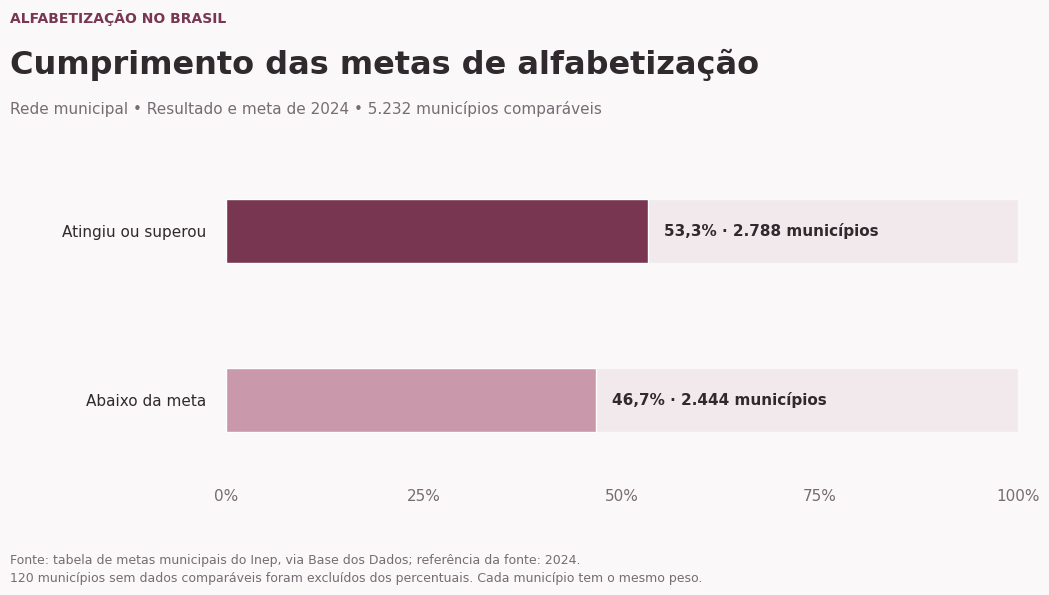

In [58]:
# Visualização do cumprimento das metas entre municípios com dados comparáveis.

ordem_situacoes = ["Atingiu ou superou", "Abaixo da meta"]

metas_comparaveis = comparacao_metas.loc[
    comparacao_metas["situacao_meta_2024"].isin(ordem_situacoes)
].copy()

grafico_metas = (
    metas_comparaveis["situacao_meta_2024"]
    .value_counts()
    .reindex(ordem_situacoes, fill_value=0)
    .rename_axis("situacao")
    .reset_index(name="qtd_municipios")
)

grafico_metas["percentual"] = (
    grafico_metas["qtd_municipios"]
    / grafico_metas["qtd_municipios"].sum()
    * 100
)

qtd_sem_comparacao = int(
    comparacao_metas["situacao_meta_2024"]
    .eq("Sem dados para comparação")
    .sum()
)

fig, ax = criar_figura(
    titulo="Cumprimento das metas de alfabetização",
    subtitulo=(
        "Rede municipal • Resultado e meta de 2024 • "
        f"{numero_br(len(metas_comparaveis))} municípios comparáveis"
    ),
    rodape=(
        "Fonte: tabela de metas municipais do Inep, via Base dos Dados; "
        "referência da fonte: 2024.\n"
        f"{numero_br(qtd_sem_comparacao)} municípios sem dados comparáveis "
        "foram excluídos dos percentuais. Cada município tem o mesmo peso."
    ),
    tamanho=(12, 6.5)
)

fig.subplots_adjust(left=0.25)

posicoes = np.arange(len(grafico_metas))

ax.barh(
    posicoes,
    100,
    height=0.38,
    color=PALETA["rosa_claro"],
    alpha=0.5
)

ax.barh(
    posicoes,
    grafico_metas["percentual"],
    height=0.38,
    color=[PALETA["marsala"], PALETA["rosa"]]
)

for posicao, linha in grafico_metas.iterrows():
    ax.text(
        linha["percentual"] + 2,
        posicao,
        f"{numero_br(linha['percentual'], 1)}% · "
        f"{numero_br(linha['qtd_municipios'])} municípios",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_yticks(posicoes)
ax.set_yticklabels(grafico_metas["situacao"], fontsize=11)
ax.set_ylim(len(grafico_metas) - 0.5, -0.5)
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x:.0f}%")
)
ax.tick_params(axis="y", pad=14)

salvar_grafico(fig, "08_cumprimento_metas_2024.png")

grafico_metas.to_csv(
    PASTA_RELATORIOS / "resumo_cumprimento_metas_2024.csv",
    index=False
)
